Using device: cpu
Compiling model...
'compile' took 0.000207 s



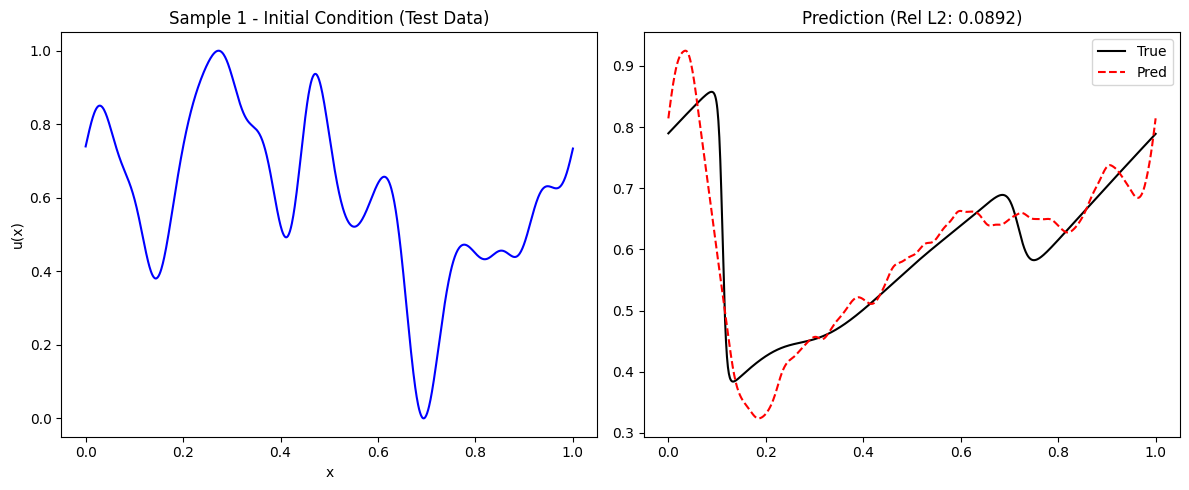

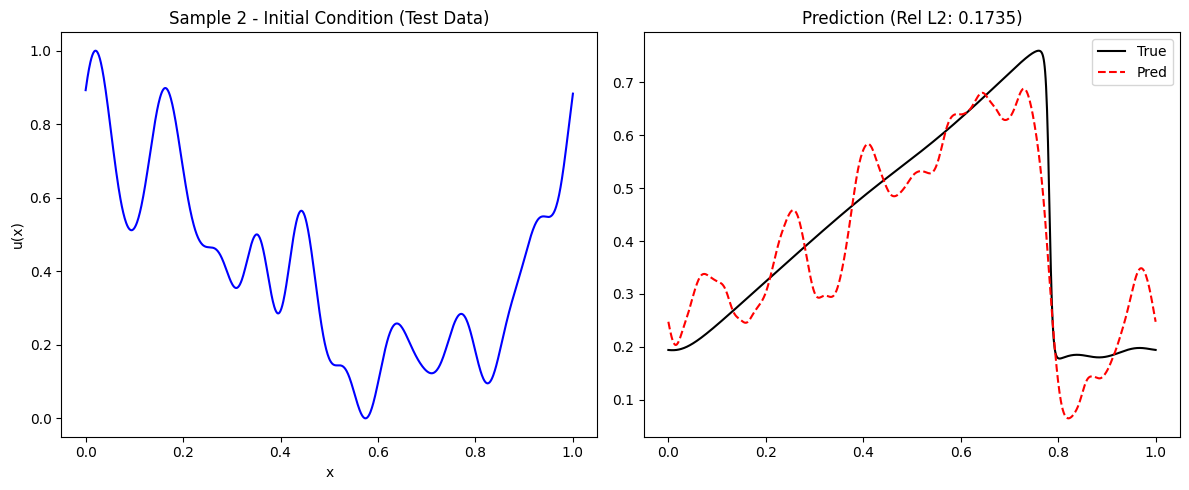

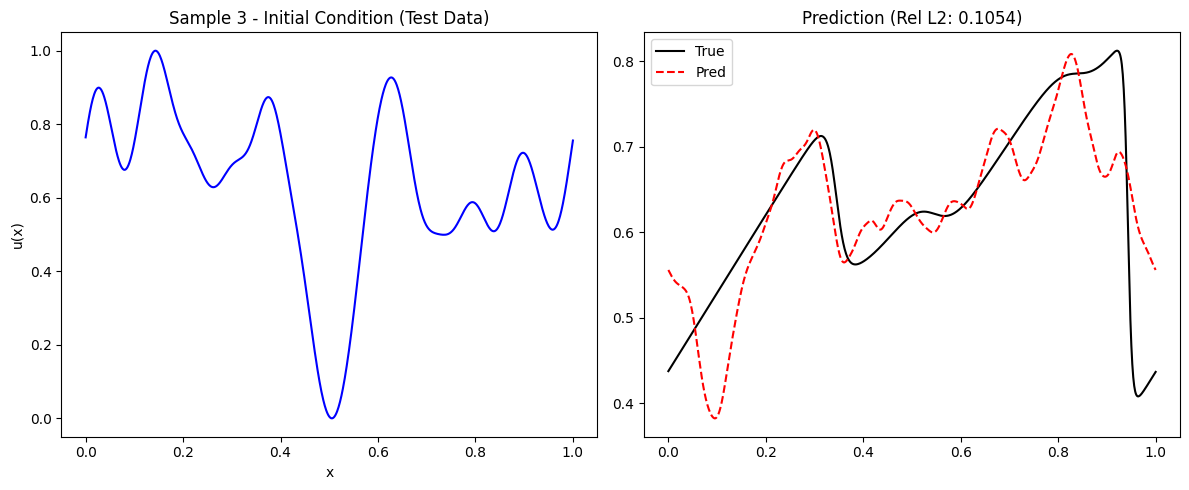

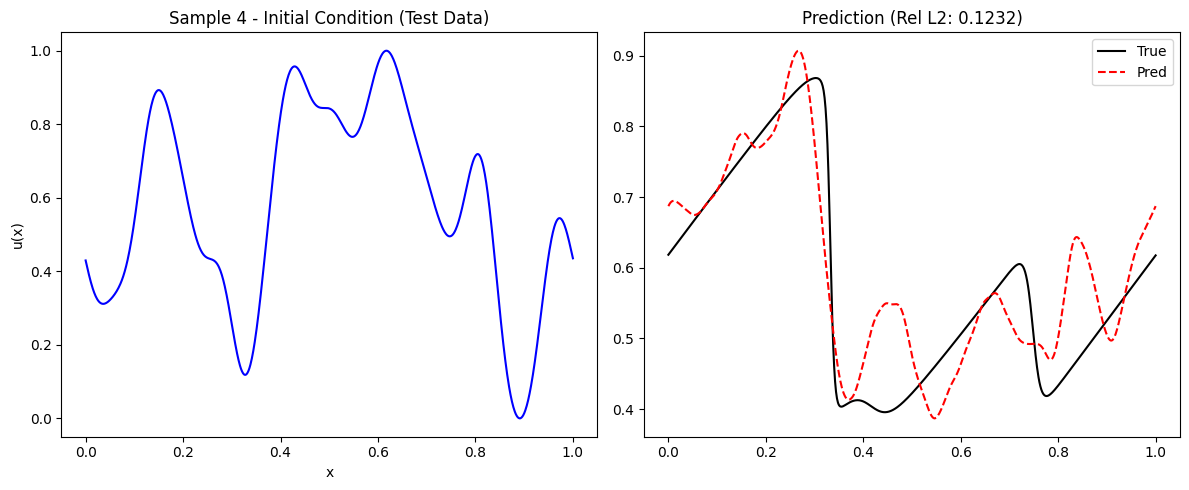

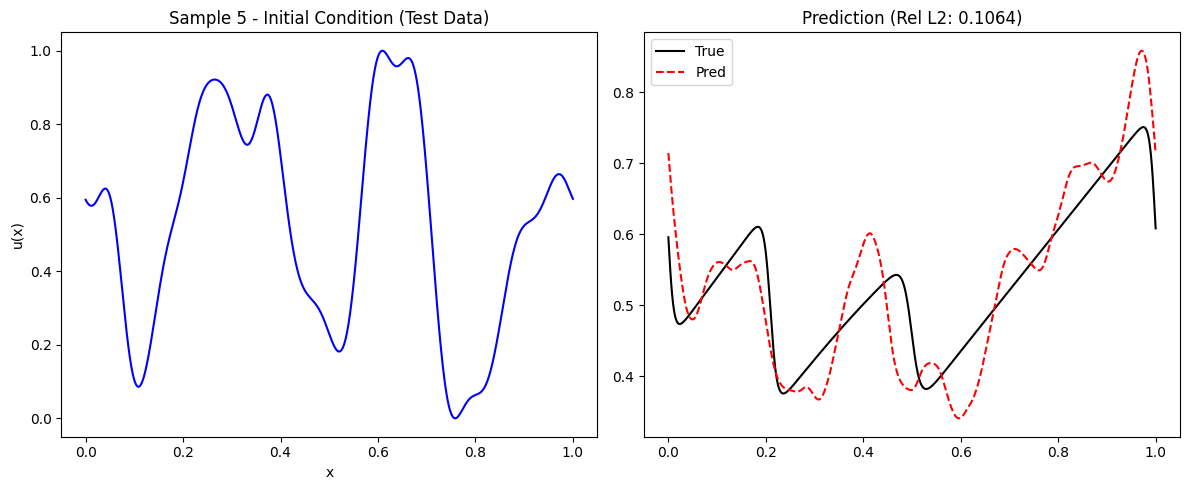

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import deepxde as dde

# === 设备配置 ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# === 特征变换（周期）===
def periodic(x):
    x = x * (2 * np.pi)
    return torch.cat(
        [torch.cos(x), torch.sin(x), torch.cos(2 * x), torch.sin(2 * x)], dim=1
    )

# === 加载测试数据 ===
def load_test_data(data_path):
    data = torch.load(data_path)
    x = data["x"].cpu().numpy().astype(np.float32)  # (N, M)
    y = data["y"].cpu().numpy().astype(np.float32)  # (N, M)

    grid = np.linspace(0, 1, x.shape[1], dtype=np.float32)[:, None]  # (M, 1)

    return x, y, grid

# === 加载模型 ===
def load_deepxde_model(model_dir, std, mean, x_train, y_train, x_test, y_test):
    m = 2 ** 10
    net = dde.maps.DeepONetCartesianProd(
        [m, 128, 128, 128, 128],
        [4, 128, 128, 128],
        "tanh",
        "Glorot normal"
    )
    net.apply_feature_transform(periodic)

    def output_transform(inputs, outputs):
        device = outputs.device
        std_t = torch.tensor(std, device=device)
        mean_t = torch.tensor(mean, device=device)
        return outputs * std_t + mean_t

    net.apply_output_transform(output_transform)

    data = dde.data.TripleCartesianProd(
        X_train=x_train,
        y_train=y_train,
        X_test=x_test,
        y_test=y_test
    )

    model = dde.Model(data, net)
    model.compile("adam", lr=0.001)
    model.restore(model_dir, device="cpu")

    return model

# === 推理 + 可视化 ===
def infer_and_plot(model, scaler, x, y_true, grid, num_samples=3):
    N = num_samples
    M = x.shape[1]

    # 转成 DeepONet 需要的输入格式（list）
    branch_inputs = [x[i] for i in range(N)]     # 长度N，每个元素形状 (M,)
    trunk_inputs = [grid[i] for i in range(M)]  # 长度M，每个元素形状 (1,)

    # 预测
    y_pred = model.predict((branch_inputs, trunk_inputs))  # (N, M)

    # 反标准化
    std = np.sqrt(scaler.var_).astype(np.float32)
    mean = scaler.mean_.astype(np.float32)
    y_pred_denorm = y_pred

    x_coords = np.linspace(0, 1, M)

    for i in range(N):
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(x_coords, x[i], 'b-')
        plt.title(f"Sample {i+1} - Initial Condition (Test Data)")
        plt.xlabel("x"); plt.ylabel("u(x)")

        plt.subplot(1, 2, 2)
        plt.plot(x_coords, y_true[i], 'k-', label='True')
        plt.plot(x_coords, y_pred_denorm[i], 'r--', label='Pred')
        rel_error = np.linalg.norm(y_pred_denorm[i] - y_true[i]) / np.linalg.norm(y_true[i])
        plt.title(f"Prediction (Rel L2: {rel_error:.4f})")
        plt.legend()
        plt.tight_layout()
        plt.show()

# === 主程序入口 ===
if __name__ == "__main__":
    model_dir = "./model.pt"  # 模型权重路径
    test_data_path = "../../../../datasets/nu0.001/dim1d_nx1024_N100_test.pt"  # 测试数据路径

    # 加载 scaler
    scaler = joblib.load("scaler.pkl")
    std = np.sqrt(scaler.var_).astype(np.float32)
    mean = scaler.mean_.astype(np.float32)

    # 加载测试数据
    x, y, grid = load_test_data(test_data_path)

    # 构造训练和测试数据，满足 TripleCartesianProd 的格式

    N_train = 10  # 训练样本数量
    N_test = 10   # 测试样本数量
    M = x.shape[1]  # 空间点数

    # branch 输入是长度为 N 的 list，每个元素形状为 (M,)
    branch_train = [x[i] for i in range(N_train)]
    branch_test = [x[i] for i in range(N_train, N_train + N_test)]

    # trunk 输入是长度为 M 的 list，每个元素形状为 (1,)
    trunk = [grid[i] for i in range(M)]

    # 标签形状 (N, M)
    y_train = y[:N_train]
    y_test = y[N_train:N_train + N_test]

    x_train_dummy = (branch_train, trunk)
    x_test_dummy = (branch_test, trunk)

    # 加载模型
    model = load_deepxde_model(
        model_dir,
        std,
        mean,
        x_train_dummy,
        y_train,
        x_test_dummy,
        y_test
    )

    # 推理 + 可视化
    infer_and_plot(model, scaler, x, y, grid, num_samples=5)


Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Using device: cpu
Compiling model...
'compile' took 2.520361 s



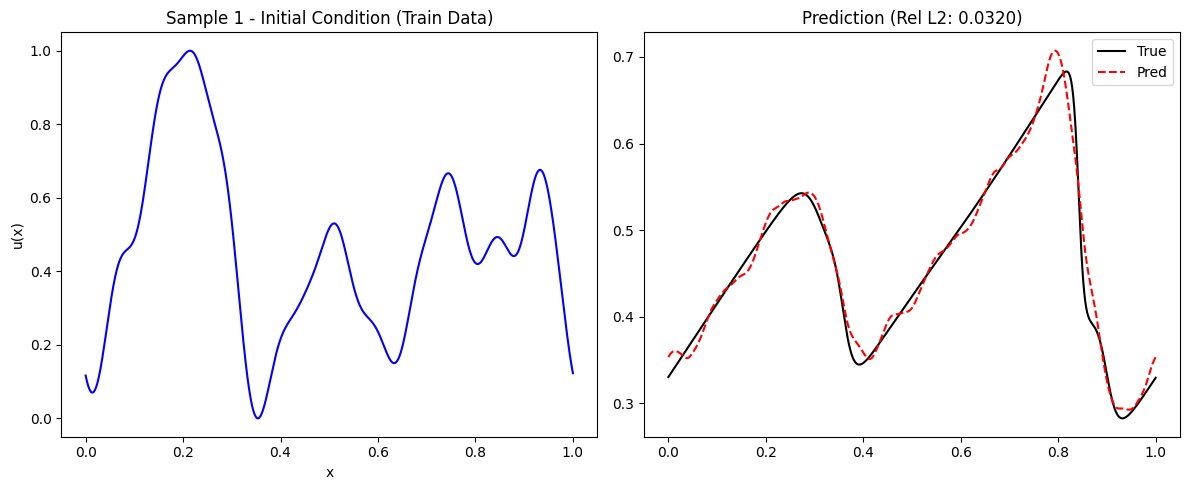

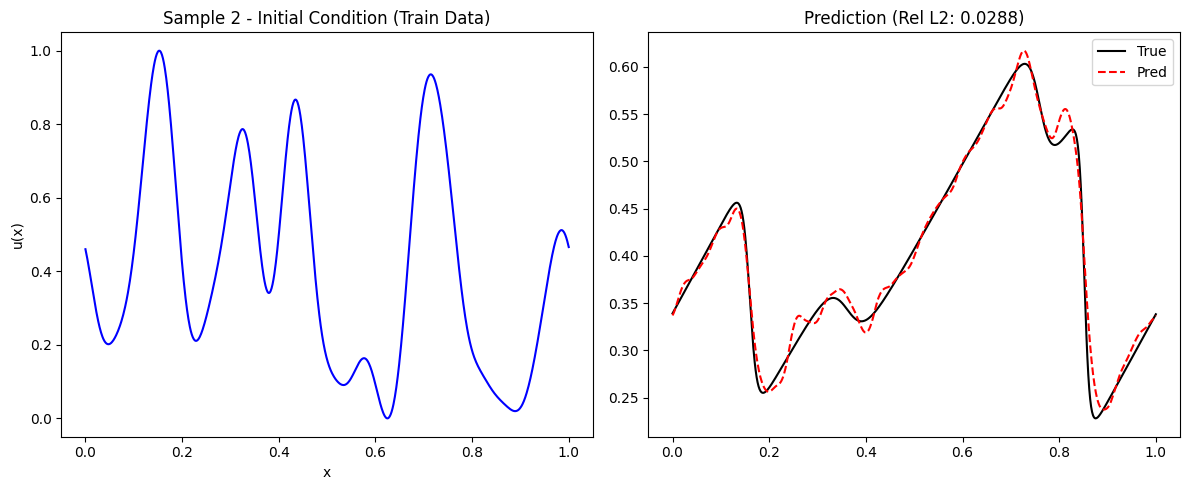

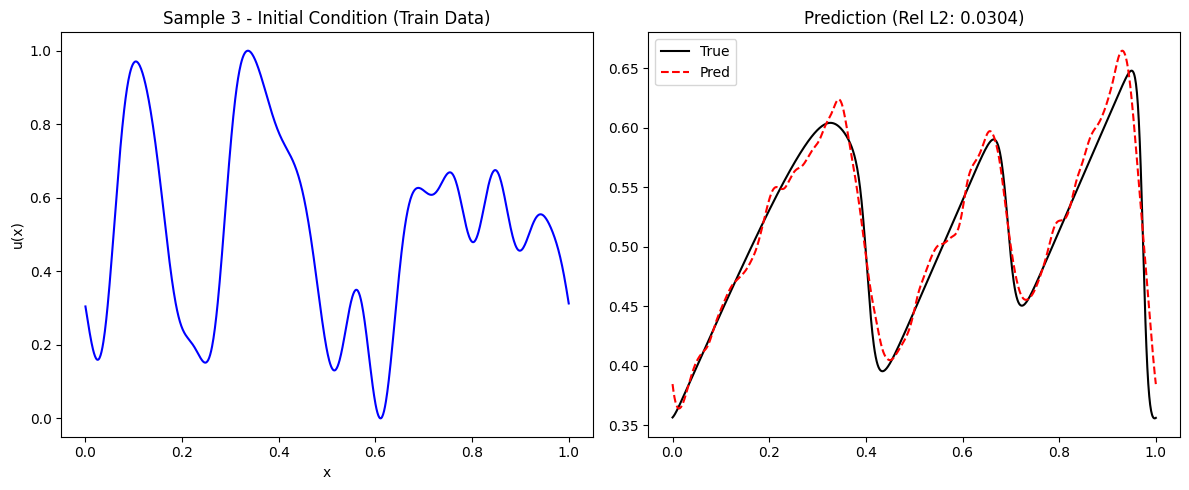

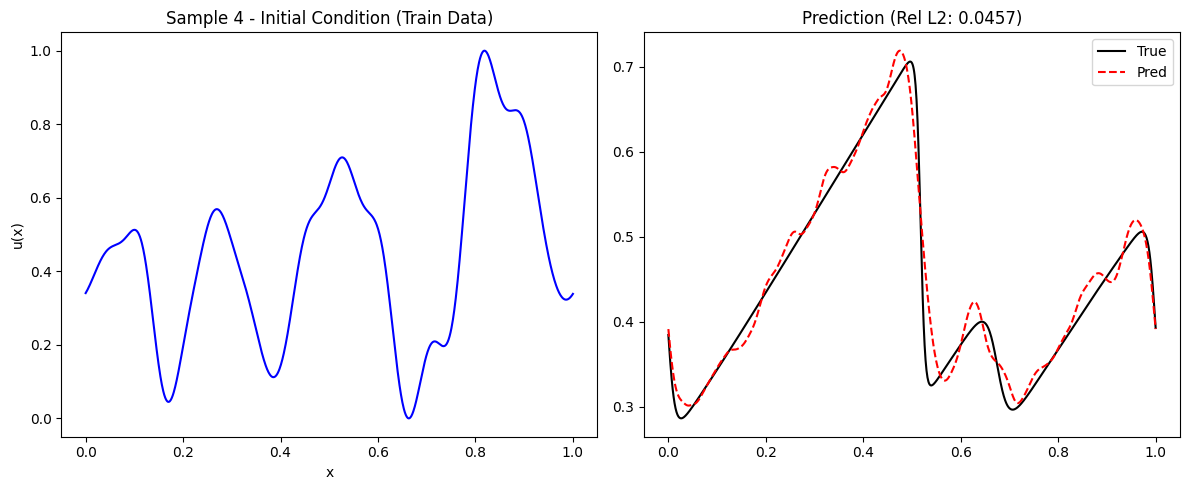

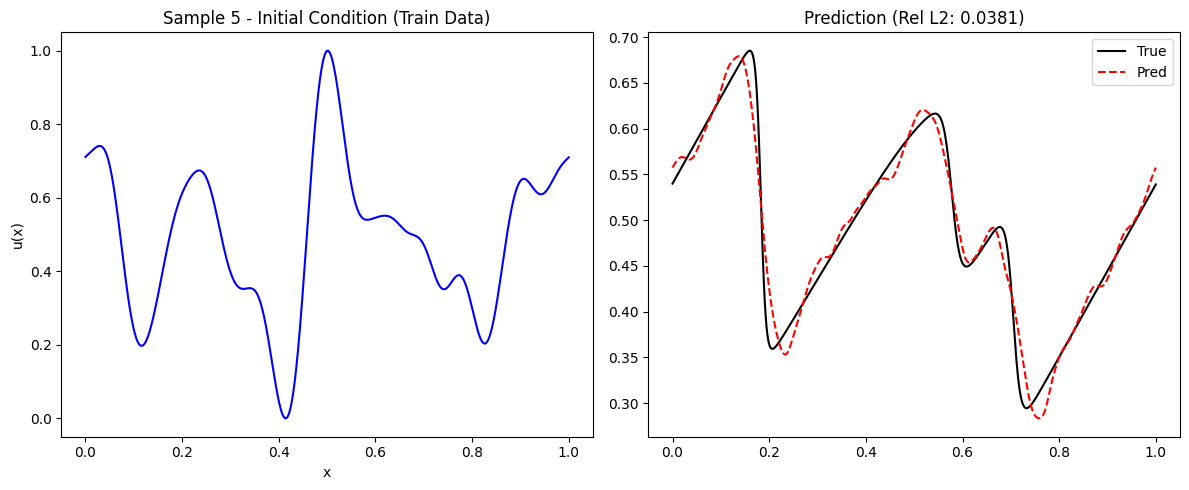

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import deepxde as dde

# === 设备配置 ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# === 特征变换（周期）===
def periodic(x):
    x = x * (2 * np.pi)
    return torch.cat(
        [torch.cos(x), torch.sin(x), torch.cos(2 * x), torch.sin(2 * x)], dim=1
    )

# === 加载测试数据 ===
def load_test_data(data_path):
    data = torch.load(data_path)
    x = data["x"].cpu().numpy().astype(np.float32)  # (N, M)
    y = data["y"].cpu().numpy().astype(np.float32)  # (N, M)

    grid = np.linspace(0, 1, x.shape[1], dtype=np.float32)[:, None]  # (M, 1)

    return x, y, grid

# === 加载模型 ===
def load_deepxde_model(model_dir, std, mean, x_train, y_train, x_test, y_test):
    m = 2 ** 10
    net = dde.maps.DeepONetCartesianProd(
        [m, 128, 128, 128, 128],
        [4, 128, 128, 128],
        "tanh",
        "Glorot normal"
    )
    net.apply_feature_transform(periodic)

    def output_transform(inputs, outputs):
        device = outputs.device
        std_t = torch.tensor(std, device=device)
        mean_t = torch.tensor(mean, device=device)
        return outputs * std_t + mean_t

    net.apply_output_transform(output_transform)

    data = dde.data.TripleCartesianProd(
        X_train=x_train,
        y_train=y_train,
        X_test=x_test,
        y_test=y_test
    )

    model = dde.Model(data, net)
    model.compile("adam", lr=0.001)
    model.restore(model_dir, device="cpu")

    return model

# === 推理 + 可视化 ===
def infer_and_plot(model, scaler, x, y_true, grid, num_samples=3):
    N = num_samples
    M = x.shape[1]

    # 转成 DeepONet 需要的输入格式（list）
    branch_inputs = [x[i] for i in range(N)]     # 长度N，每个元素形状 (M,)
    trunk_inputs = [grid[i] for i in range(M)]  # 长度M，每个元素形状 (1,)

    # 预测
    y_pred = model.predict((branch_inputs, trunk_inputs))  # (N, M)

    # 反标准化
    std = np.sqrt(scaler.var_).astype(np.float32)
    mean = scaler.mean_.astype(np.float32)
    y_pred_denorm = y_pred

    x_coords = np.linspace(0, 1, M)

    for i in range(N):
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(x_coords, x[i], 'b-')
        plt.title(f"Sample {i+1} - Initial Condition (Train Data)")
        plt.xlabel("x"); plt.ylabel("u(x)")

        plt.subplot(1, 2, 2)
        plt.plot(x_coords, y_true[i], 'k-', label='True')
        plt.plot(x_coords, y_pred_denorm[i], 'r--', label='Pred')
        rel_error = np.linalg.norm(y_pred_denorm[i] - y_true[i]) / np.linalg.norm(y_true[i])
        plt.title(f"Prediction (Rel L2: {rel_error:.4f})")
        plt.legend()
        plt.tight_layout()
        plt.show()

# === 主程序入口 ===
if __name__ == "__main__":
    model_dir = "./model.pt"  # 模型权重路径
    test_data_path = "../../../../datasets/nu0.001/dim1d_nx1024_N1400_train.pt"  # 测试数据路径

    # 加载 scaler
    scaler = joblib.load("scaler.pkl")
    std = np.sqrt(scaler.var_).astype(np.float32)
    mean = scaler.mean_.astype(np.float32)

    # 加载测试数据
    x, y, grid = load_test_data(test_data_path)

    # 构造训练和测试数据，满足 TripleCartesianProd 的格式

    N_train = 10  # 训练样本数量
    N_test = 10   # 测试样本数量
    M = x.shape[1]  # 空间点数

    # branch 输入是长度为 N 的 list，每个元素形状为 (M,)
    branch_train = [x[i] for i in range(N_train)]
    branch_test = [x[i] for i in range(N_train, N_train + N_test)]

    # trunk 输入是长度为 M 的 list，每个元素形状为 (1,)
    trunk = [grid[i] for i in range(M)]

    # 标签形状 (N, M)
    y_train = y[:N_train]
    y_test = y[N_train:N_train + N_test]

    x_train_dummy = (branch_train, trunk)
    x_test_dummy = (branch_test, trunk)

    # 加载模型
    model = load_deepxde_model(
        model_dir,
        std,
        mean,
        x_train_dummy,
        y_train,
        x_test_dummy,
        y_test
    )

    # 推理 + 可视化
    infer_and_plot(model, scaler, x, y, grid, num_samples=5)